# Customer churn prediction

Lib import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

Load dataset and EDA

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')
print("\n Shape (R,C): ",df.shape)


 Shape (R,C):  (7043, 21)


In [46]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [47]:
print(df.tail())

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
7038              Yes         Yes         Yes  

In [51]:
df.dtypes

customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Quick datatype processing:

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"}).astype("object")

### Describing variables:

In [52]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [53]:
print("Missing values:\n\n", df.isnull().sum())

Missing values:

 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [54]:
# Target variable distribution
print("Churn Value Counts:")
print(df["Churn"].value_counts())

Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


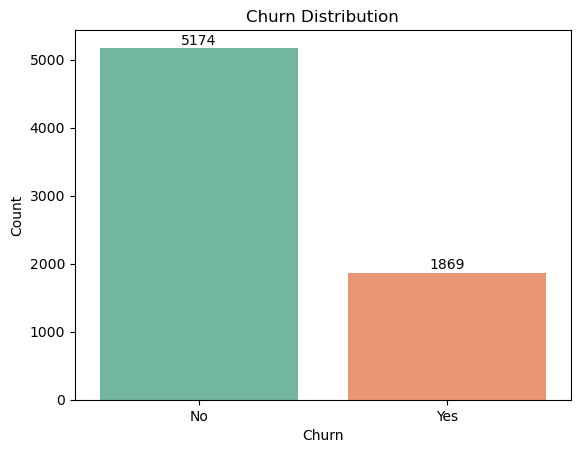

In [55]:
churn_counts = df["Churn"].value_counts()
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette="Set2")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

Categorics

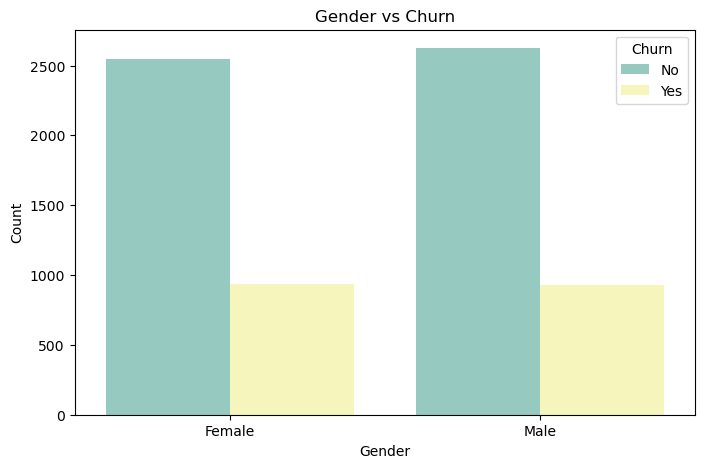

In [66]:
# plot of gender x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="gender", hue="Churn", palette="Set3")
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

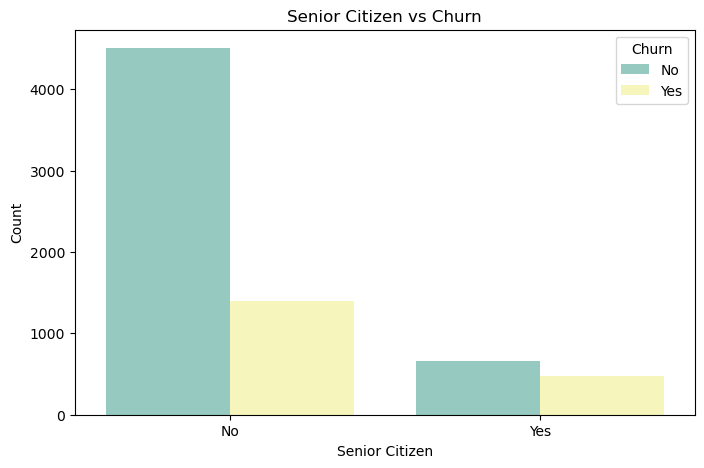

In [62]:
#plot of senior citizen x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn", palette="Set3")
plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

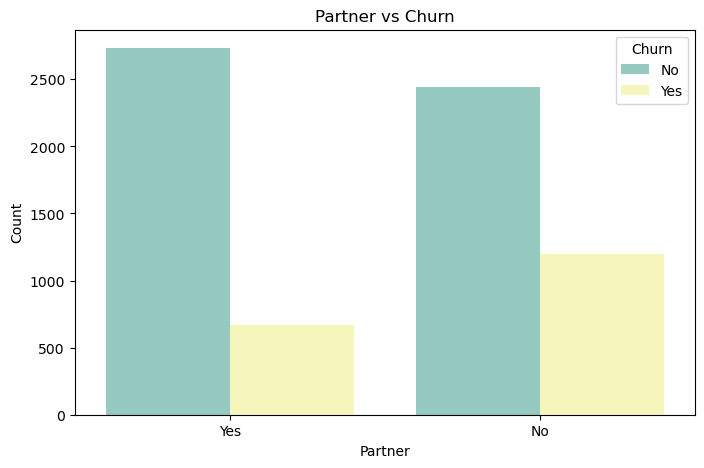

In [64]:
#plot of partner x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Partner", hue="Churn", palette="Set3")
plt.title("Partner vs Churn")
plt.xlabel("Partner")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

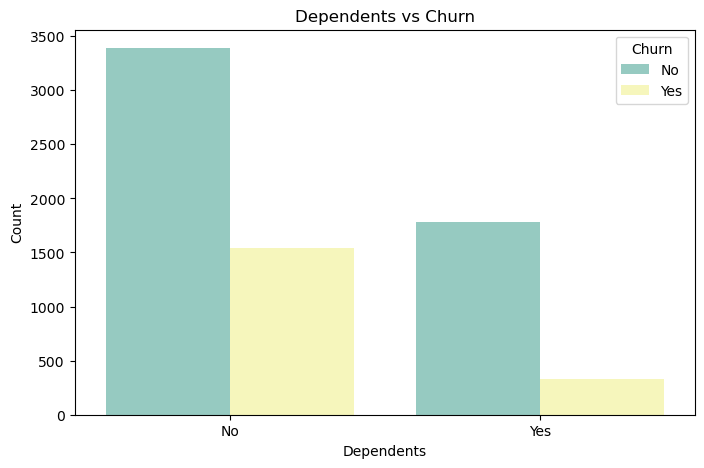

In [65]:
#plot of Dependents x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Dependents", hue="Churn", palette="Set3")
plt.title("Dependents vs Churn")
plt.xlabel("Dependents")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

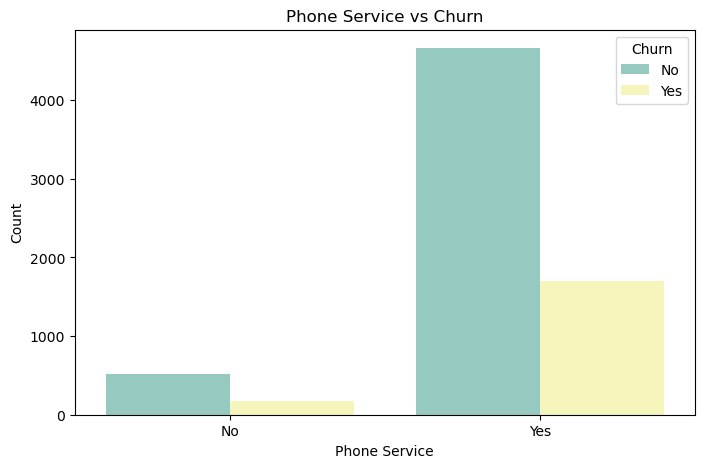

In [67]:
#plot of Phone Service x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="PhoneService", hue="Churn", palette="Set3")
plt.title("Phone Service vs Churn")
plt.xlabel("Phone Service")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

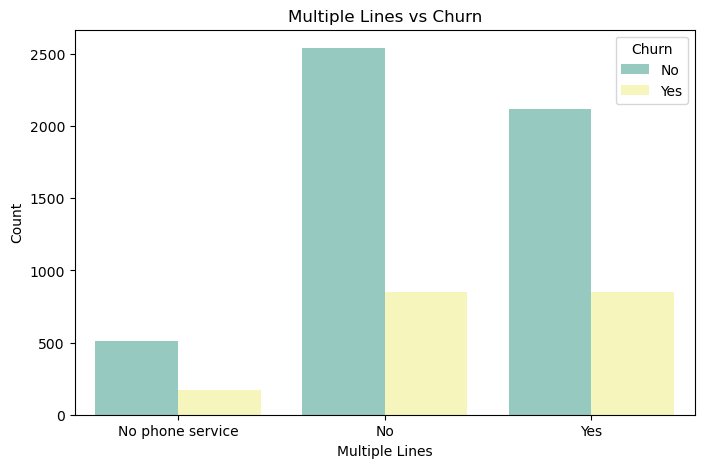

In [68]:
#plot of Multiple Lines x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="MultipleLines", hue="Churn", palette="Set3")
plt.title("Multiple Lines vs Churn")
plt.xlabel("Multiple Lines")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

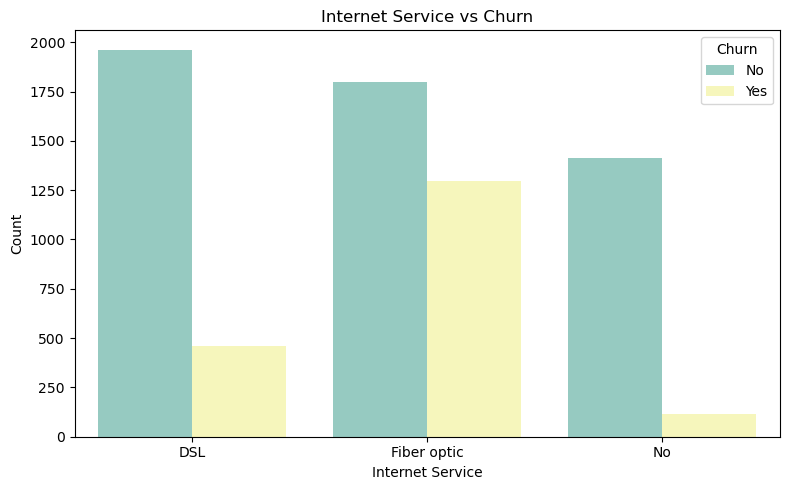

In [74]:
#plot of Internet Service x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn", palette="Set3")
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_internet_service_churn.png")
plt.show()

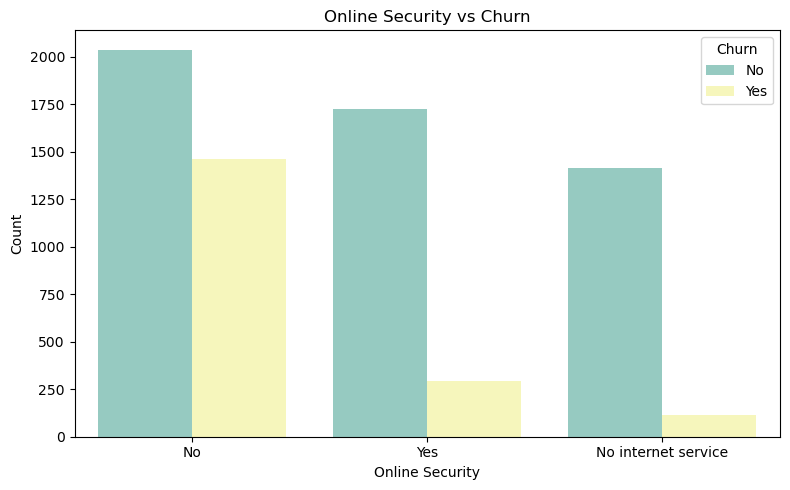

In [75]:
#plot of Online Security x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="OnlineSecurity", hue="Churn", palette="Set3")
plt.title("Online Security vs Churn")
plt.xlabel("Online Security")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_online_security_churn.png")
plt.show()

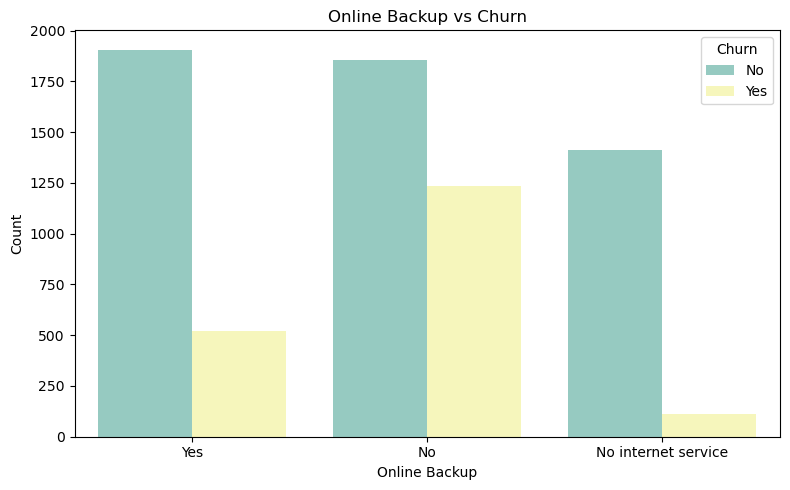

In [76]:
#plot of Online Backup x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="OnlineBackup", hue="Churn", palette="Set3")
plt.title("Online Backup vs Churn")
plt.xlabel("Online Backup")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_online_backup_churn.png")
plt.show()

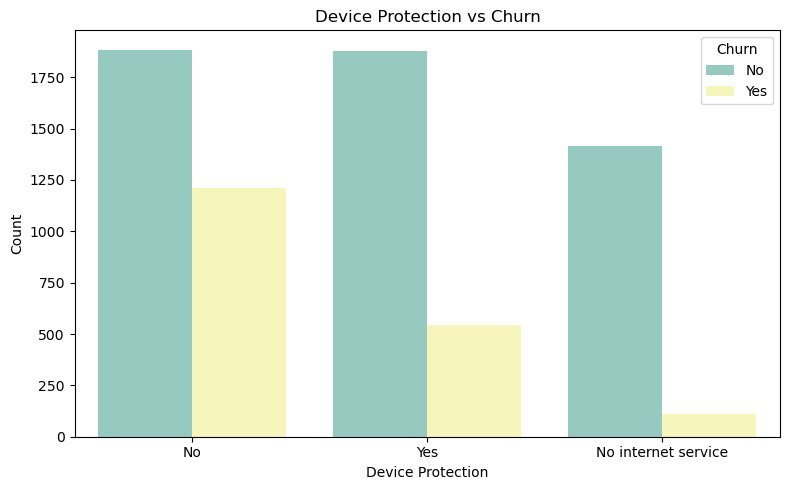

In [ ]:
#plot of Device Protection x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="DeviceProtection", hue="Churn", palette="Set3")
plt.title("Device Protection vs Churn")
plt.xlabel("Device Protection")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_device_protection_churn.png")
plt.show()

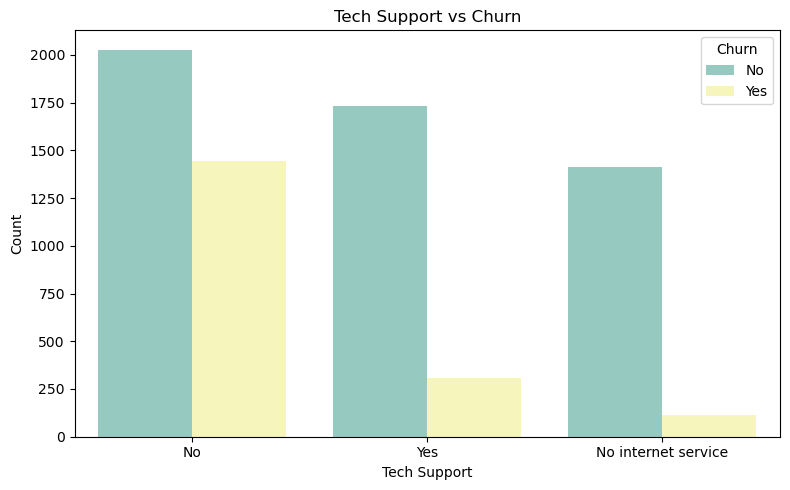

In [79]:
#plot of TechSupport x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="TechSupport", hue="Churn", palette="Set3")
plt.title("Tech Support vs Churn")
plt.xlabel("Tech Support")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_tech_support_churn.png")
plt.show()

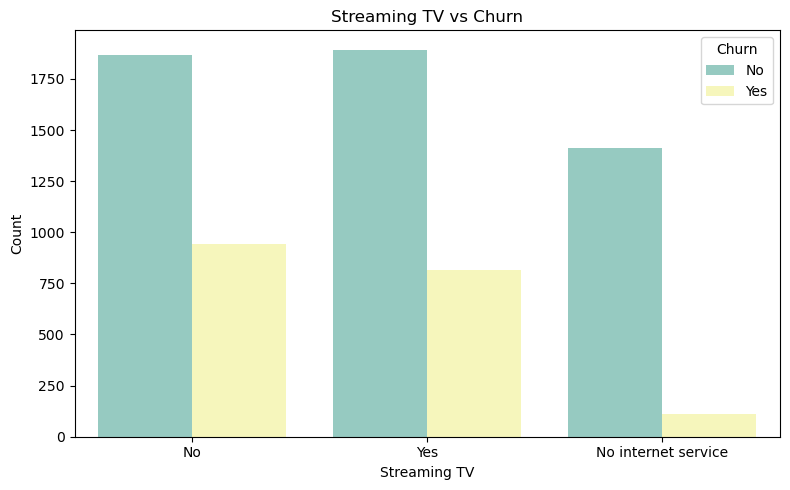

In [80]:
#plot of StreamingTV x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="StreamingTV", hue="Churn", palette="Set3")
plt.title("Streaming TV vs Churn")
plt.xlabel("Streaming TV")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_streaming_tv_churn.png")
plt.show()

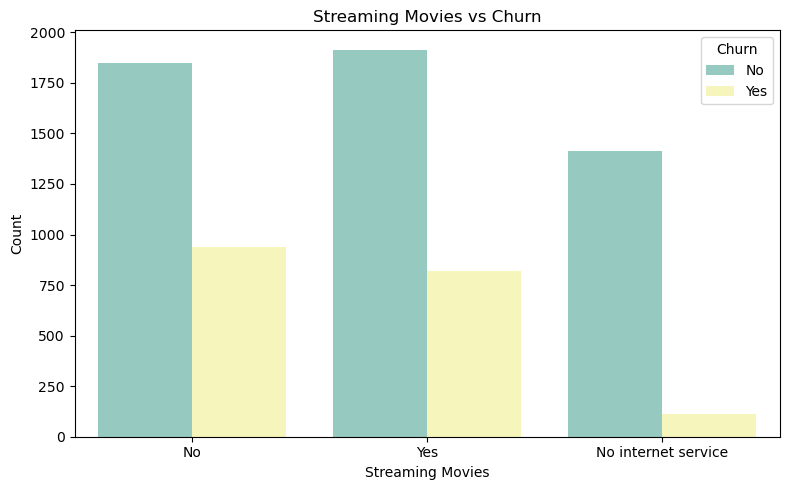

In [81]:
#plot of StreamingMovies x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="StreamingMovies", hue="Churn", palette="Set3")
plt.title("Streaming Movies vs Churn")
plt.xlabel("Streaming Movies")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_streaming_movies_churn.png")
plt.show()

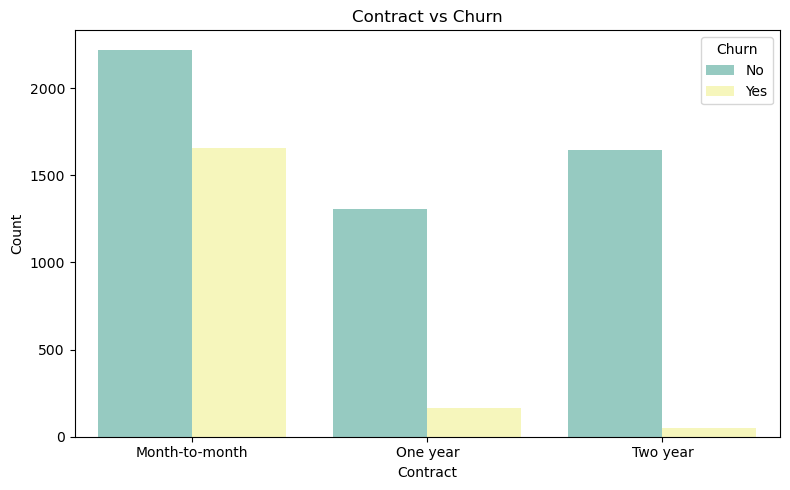

In [82]:
#plot of Contract x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set3")
plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_contract_churn.png")
plt.show()

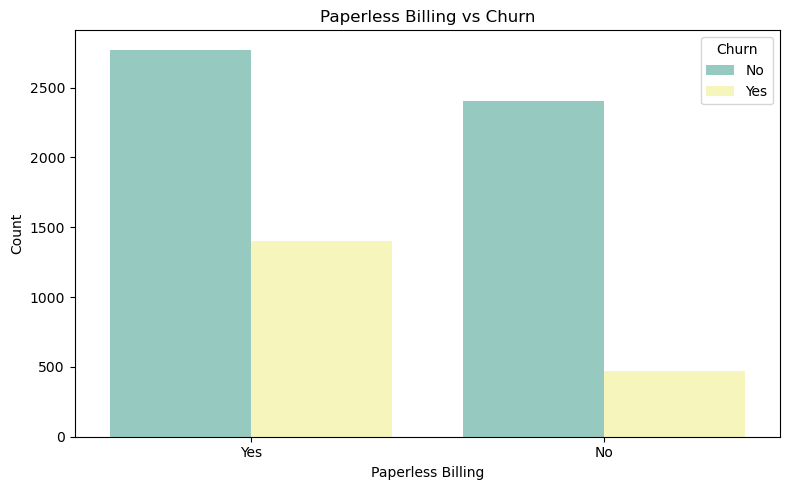

In [83]:
#plot of PaperlessBilling x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="PaperlessBilling", hue="Churn", palette="Set3")
plt.title("Paperless Billing vs Churn")
plt.xlabel("Paperless Billing")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_paperless_billing_churn.png")
plt.show()

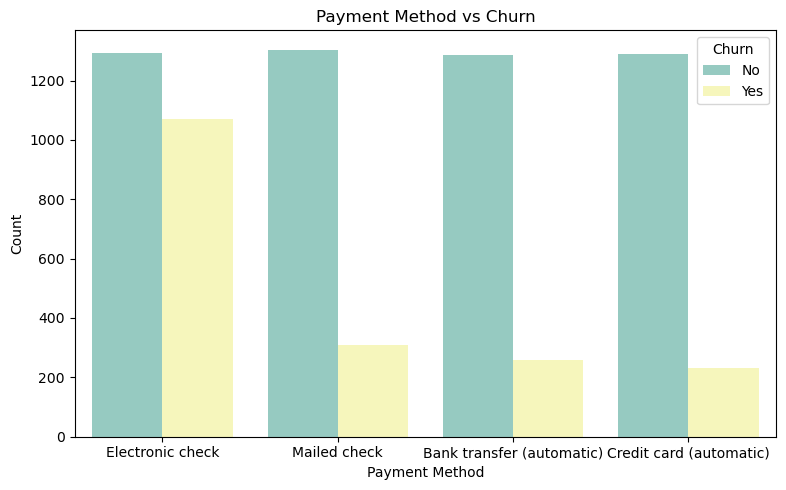

In [84]:
#plot of PaymentMethod x churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn", palette="Set3")
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("plot_payment_method_churn.png")
plt.show()

Countables

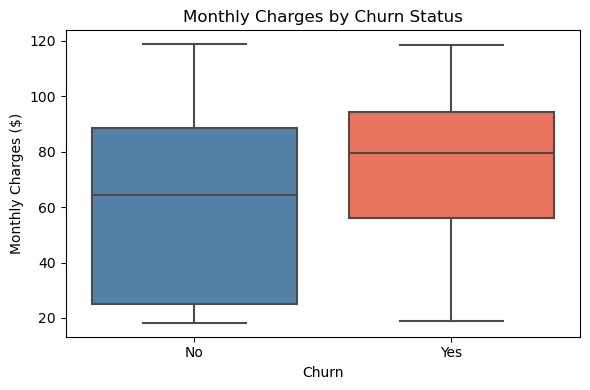

In [71]:
#plot o monthly charges x churn
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["steelblue", "tomato"])
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig("plot2_monthly_charges_boxplot.png")
plt.show()

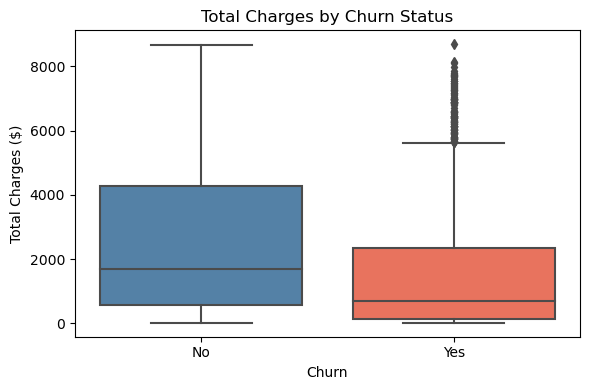

In [72]:
#plot o total charges x churn
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="TotalCharges", data=df, palette=["steelblue", "tomato"])
plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges ($)")
plt.tight_layout()
plt.savefig("plot_total_charges_boxplot.png")
plt.show()

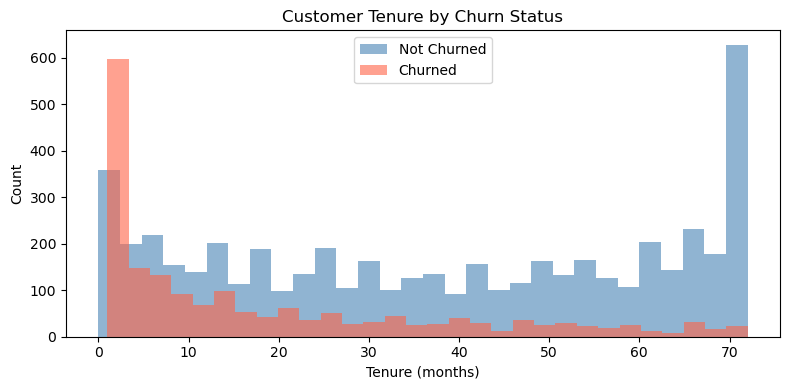

In [73]:
# Plot: Tenure distribution by churn (w/ histogram)
plt.figure(figsize=(8, 4))
df[df["Churn"] == "No"]["tenure"].plot(kind="hist", bins=30, alpha=0.6, color="steelblue", label="Not Churned")
df[df["Churn"] == "Yes"]["tenure"].plot(kind="hist", bins=30, alpha=0.6, color="tomato", label="Churned")
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("plot_tenure_histogram.png")
plt.show()

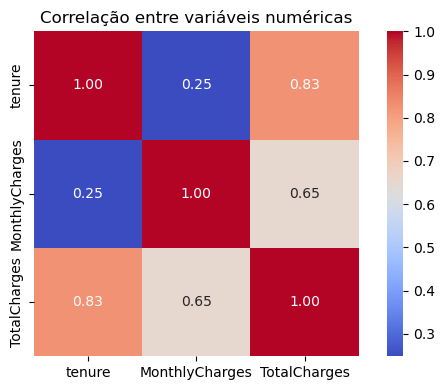

In [12]:
# Heatmap correlation between numerical variables
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

Preprocessing

In [6]:
df.drop(columns=["customerID"], inplace=True) #removing ID column because it is not useful for prediction

In [7]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
print("Total of null values:", df.isnull().sum().sum())

Total of null values: 0


In [8]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [9]:
# Separating features (X) from the target column (y) 
X = df.drop(columns=["Churn"])   
y = df["Churn"]                 
 
print("\nFeatures shape:", X.shape)
print("Target shape  :", y.shape)


Features shape: (7043, 19)
Target shape  : (7043,)


In [10]:
#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)


In [13]:
# Feature scaling just for the numerical columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)
X_train_scaled[num_cols].head()

X_train_scaled shape: (5634, 19)
X_test_scaled shape : (1409, 19)


,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.263289
3151,-0.711743,0.337478,-0.504814
4860,-0.793155,-0.809013,-0.751213
3867,-0.263980,0.284384,-0.173699
3810,-1.281624,-0.676279,-0.990851


## Model Training & Comparison

In [14]:
# One-hot encode categorical columns
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

X_train_enc = pd.get_dummies(X_train_scaled, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_scaled,  columns=cat_cols, drop_first=True)

# Align columns (in case test set is missing some dummy cols)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

print("Encoded train shape:", X_train_enc.shape)


Encoded train shape: (5634, 30)


In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=11),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

# Convert to contiguous numpy arrays to avoid sklearn/numpy compatibility issues
Xtr = np.ascontiguousarray(X_train_enc.values, dtype=np.float64)
Xte = np.ascontiguousarray(X_test_enc.values,  dtype=np.float64)

results = []
for name, model in models.items():
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba), 4),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6582,0.5561,0.6029,0.8420
3,Gradient Boosting,0.7942,0.6419,0.5080,0.5672,0.8360
2,Random Forest,0.7913,0.6342,0.5053,0.5625,0.8263
1,KNN,0.7793,0.5887,0.5588,0.5734,0.8133


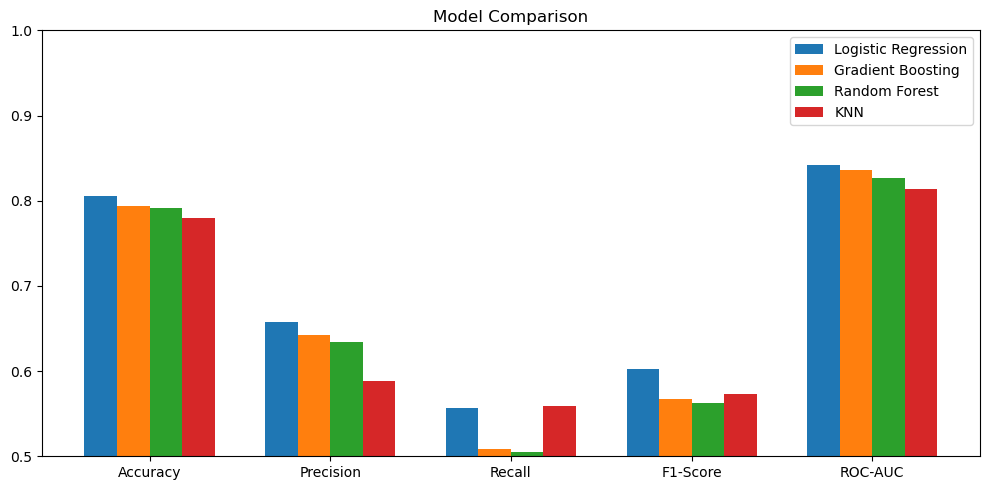

In [96]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.18

for i, row in results_df.iterrows():
    ax.bar(x + list(results_df.index).index(i) * width,
           [row[m] for m in metrics], width, label=row["Model"])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Comparison")
ax.legend()
plt.tight_layout()
plt.show()


Best k: 33
Best accuracy: 0.8013


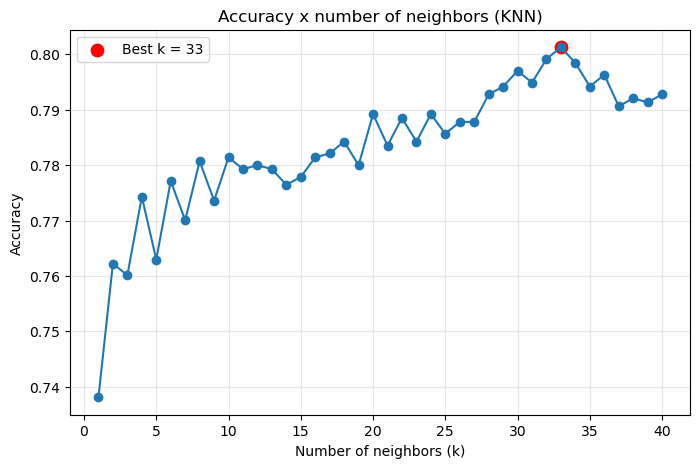

In [22]:
# Best K for KNN
k_values = range(1, 41)
acc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtr, y_train)
    y_pred_k = knn.predict(Xte)
    acc_scores.append(accuracy_score(y_test, y_pred_k))

best_idx = int(np.argmax(acc_scores))
best_k = list(k_values)[best_idx]
best_acc = acc_scores[best_idx]

print(f"Best k: {best_k}")
print(f"Best accuracy: {best_acc:.4f}")

# update the model with the best k
models["KNN"] = KNeighborsClassifier(n_neighbors=best_k).fit(Xtr, y_train)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), acc_scores, marker="o")
plt.scatter(best_k, best_acc, color="red", s=80, label=f"Best k = {best_k}")
plt.title("Accuracy x number of neighbors (KNN)")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

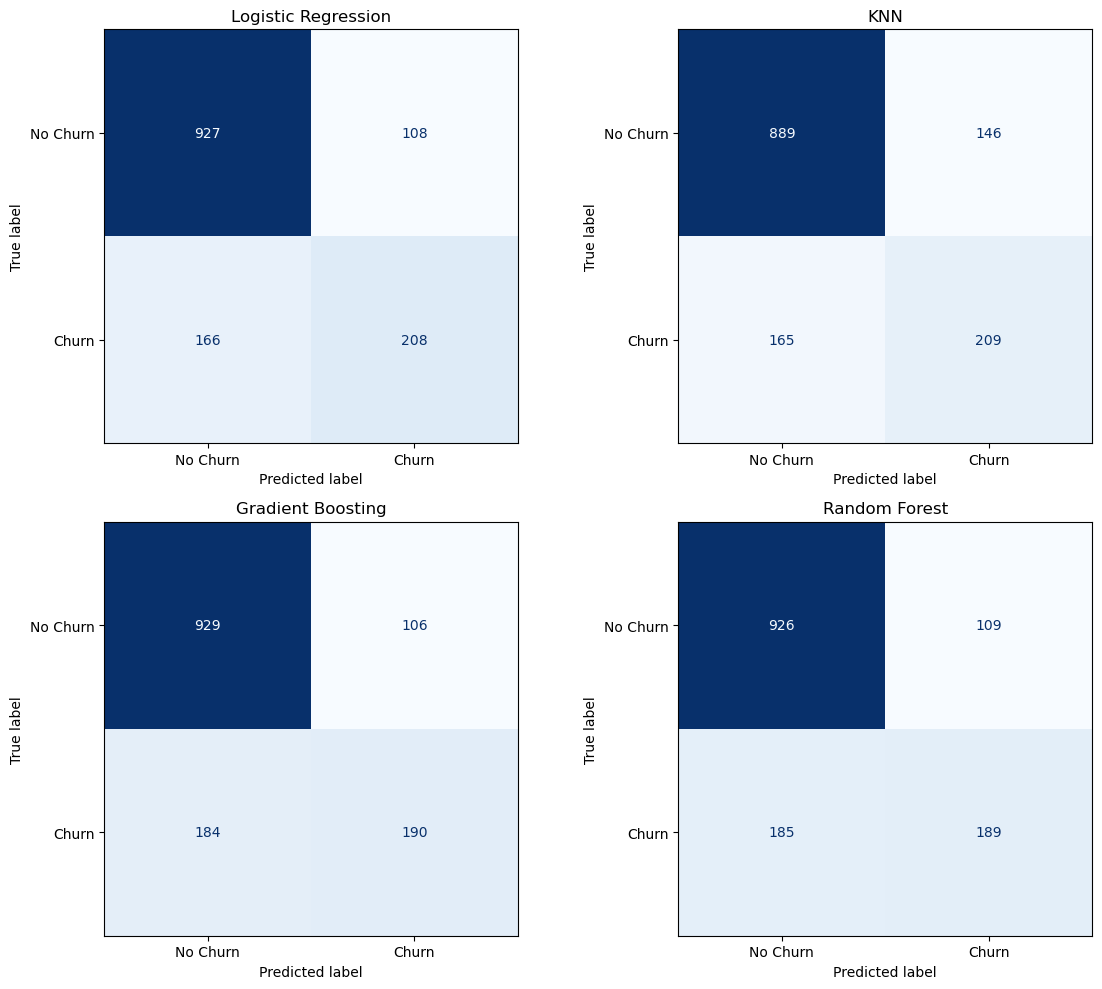

In [ ]:
# models confusion matrix
modelos_cm = {
    "Logistic Regression": models["Logistic Regression"],
    "KNN": models["KNN"],
    "Gradient Boosting": models["Gradient Boosting"],
    "Random Forest": models["Random Forest"],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (nome, modelo) in zip(axes, modelos_cm.items()):
    y_pred_model = modelo.predict(Xte)
    cm = confusion_matrix(y_test, y_pred_model)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(nome)

plt.tight_layout()
plt.show()

In [27]:
# Seleciona o melhor modelo já treinado
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

# Predições no treino e no teste
y_train_pred = best_model.predict(Xtr)
y_test_pred = best_model.predict(Xte)

y_train_proba = best_model.predict_proba(Xtr)[:, 1]
y_test_proba = best_model.predict_proba(Xte)[:, 1]

# Métricas
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

train_gap_acc = train_acc - test_acc
train_gap_auc = train_auc - test_auc

# Regras simples de checagem
if (train_gap_acc > 0.05 or train_gap_auc > 0.05) and (train_acc >= 0.80 or train_auc >= 0.85):
    status = "OVERFITTING"
    message = "Model impacted by overfitting."
elif train_acc < 0.75 and test_acc < 0.75 and train_auc < 0.80 and test_auc < 0.80:
    status = "UNDERFITTING"
    message = "Model is too simple."
else:
    status = "GOOD MODEL"
    message = "Model shows good balance between training and testing."

print(f"Evaluated model: {best_model_name}")
print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
print(f"Train ROC-AUC : {train_auc:.4f} | Test ROC-AUC : {test_auc:.4f}")
print(f"Status: {status}")
print(f"Final Quality: {message}")

Evaluated model: Logistic Regression
Train Accuracy: 0.8053 | Test Accuracy: 0.8055
Train ROC-AUC : 0.8492 | Test ROC-AUC : 0.8420
Status: GOOD MODEL
Final Quality: Model shows good balance between training and testing.


## Feature importance

,Feature,Coefficient,AbsCoefficient
25,Contract_Two year,-1.330078,1.330078
0,tenure,-1.240921,1.240921
10,InternetService_Fiber optic,1.210419,1.210419
24,Contract_One year,-0.687451,0.687451
2,TotalCharges,0.512710,0.512710
1,MonthlyCharges,-0.500694,0.500694
23,StreamingMovies_Yes,0.387918,0.387918
21,StreamingTV_Yes,0.387230,0.387230
28,PaymentMethod_Electronic check,0.383453,0.383453
26,PaperlessBilling_Yes,0.372422,0.372422


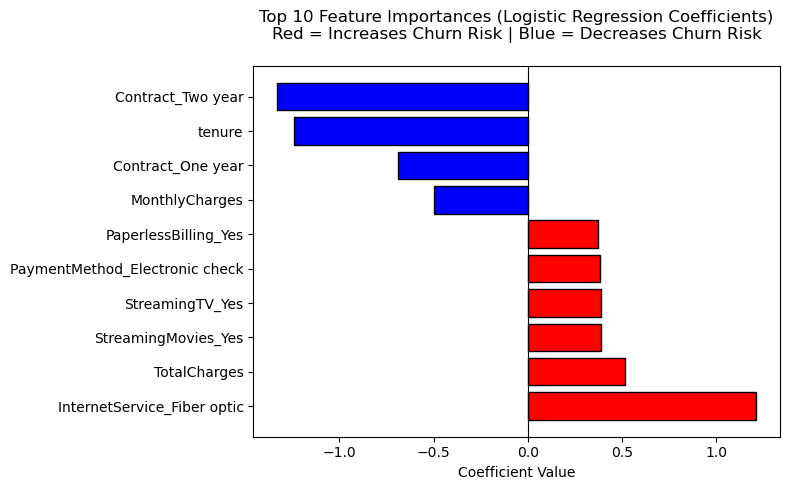

In [34]:
log_reg = models["Logistic Regression"]

coef_df = pd.DataFrame({
    "Feature": X_train_enc.columns,
    "Coefficient": log_reg.coef_[0]
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

display(coef_df)

top_n = 10
top_features = coef_df.head(top_n).sort_values("Coefficient")

plt.figure(figsize=(8, 5))
colors = ["red" if c > 0 else "blue" for c in top_features["Coefficient"]]
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors, edgecolor="black")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Top 10 Feature Importances (Logistic Regression Coefficients)\nRed = Increases Churn Risk | Blue = Decreases Churn Risk\n")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()

## Pre-deploy: Crossvalidation and probability calibration

In [39]:
# Pipeline improvement: preprocessing inside of crossvalidation
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
}

cv_scores = cross_validate(lr_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "LogLoss"],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean(),
        -cv_scores["test_neg_log_loss"].mean(),
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std(),
        cv_scores["test_roc_auc"].std(),
        cv_scores["test_neg_log_loss"].std(),
    ],
})

cv_summary.round(4)

,Metric,Mean,Std
0,Accuracy,0.8055,0.0114
1,Precision,0.6591,0.0224
2,Recall,0.5516,0.0330
3,F1,0.6004,0.0286
4,ROC-AUC,0.8450,0.0134
5,LogLoss,0.4174,0.0143


,Model,Brier,LogLoss,ROC-AUC
0,Logistic (uncalibrated),0.1380,0.4204,0.8420
1,Logistic (calibrated),0.1379,0.4202,0.8421


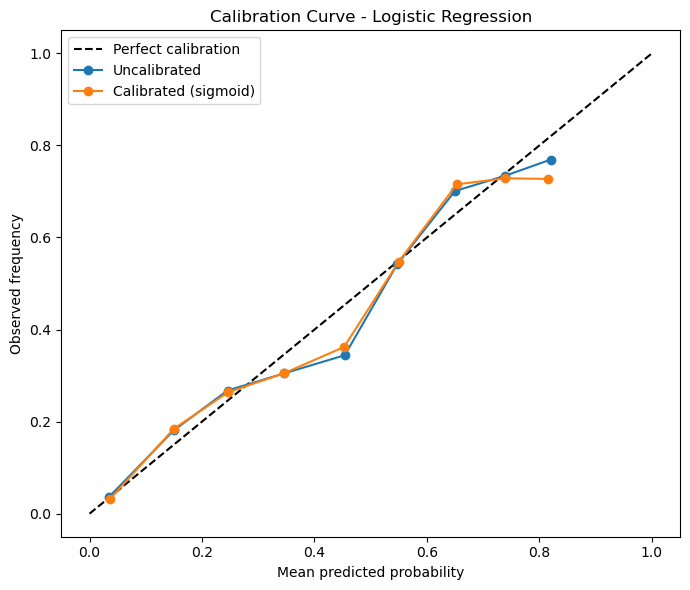

In [ ]:
# Without calibration training
lr_pipeline.fit(X_train, y_train)
prob_uncal = lr_pipeline.predict_proba(X_test)[:, 1]

# Probability calibration (Platt scaling / sigmoid)
calibrated_lr = CalibratedClassifierCV(estimator=lr_pipeline, method="sigmoid", cv=5)
calibrated_lr.fit(X_train, y_train)
prob_cal = calibrated_lr.predict_proba(X_test)[:, 1]

calibration_comparison = pd.DataFrame([
    {
        "Model": "Logistic (uncalibrated)",
        "Brier": brier_score_loss(y_test, prob_uncal),
        "LogLoss": log_loss(y_test, prob_uncal),
        "ROC-AUC": roc_auc_score(y_test, prob_uncal),
    },
    {
        "Model": "Logistic (calibrated)",
        "Brier": brier_score_loss(y_test, prob_cal),
        "LogLoss": log_loss(y_test, prob_cal),
        "ROC-AUC": roc_auc_score(y_test, prob_cal),
    },
]).round(4)

display(calibration_comparison)

# Calibration curves
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, prob_uncal, n_bins=10, strategy="uniform")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, prob_cal, n_bins=10, strategy="uniform")

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(mean_pred_uncal, frac_pos_uncal, marker="o", label="Uncalibrated")
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="Calibrated (sigmoid)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold definition cost oriented (recall priorization)

Selection rule: recall >= 0.75 + lowest cost
Recommended threshold: 0.15
Precision: 0.4381
Recall:    0.9171
F1-score:  0.5929
FP: 440 | FN: 31 | Cost: 595.0


,threshold,precision,recall,f1,fp,fn,business_cost
10,0.15,0.4381,0.9171,0.5929,440,31,595.0
9,0.14,0.4334,0.9225,0.5897,451,29,596.0
13,0.18,0.4545,0.8957,0.6031,402,39,597.0
11,0.16,0.4421,0.9091,0.5949,429,34,599.0
8,0.13,0.4268,0.9278,0.5847,466,27,601.0
12,0.17,0.4450,0.8984,0.5952,419,38,609.0
14,0.19,0.4608,0.8797,0.6048,385,45,610.0
5,0.10,0.4043,0.9545,0.5680,526,17,611.0
7,0.12,0.4148,0.9305,0.5738,491,26,621.0
6,0.11,0.4077,0.9385,0.5684,510,23,625.0


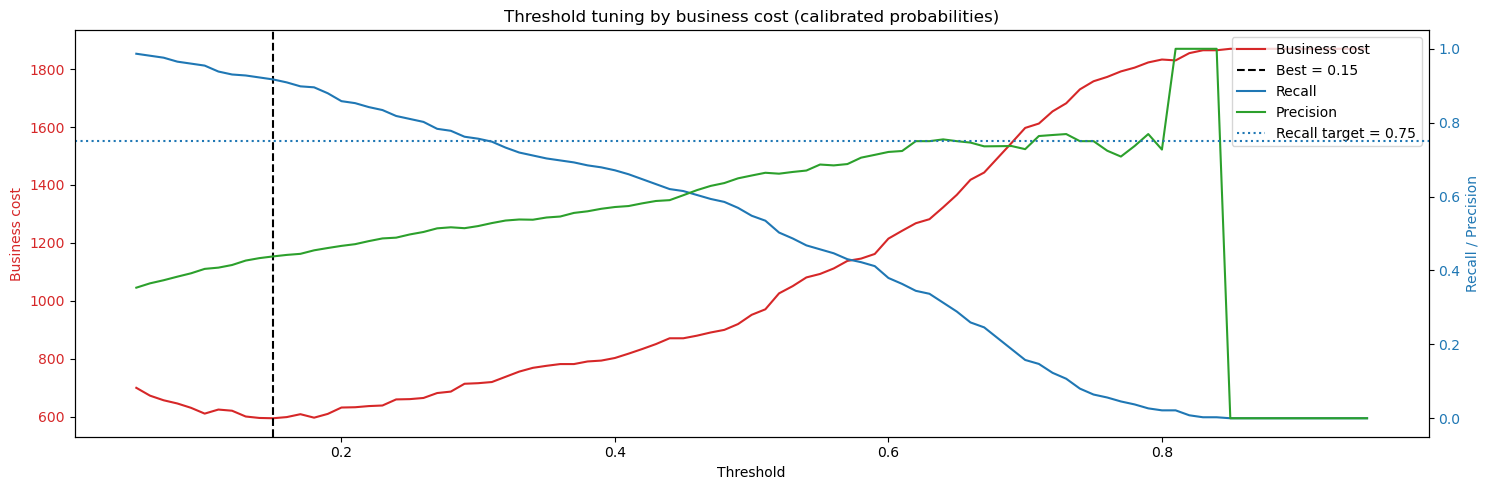

In [44]:
# Business cost (adjust according to the company)
# Example: losing a churner (FN) costs 5x more than triggering retention unnecessarily (FP)
cost_fp = 1.0
cost_fn = 5.0
recall_target = 0.75

thresholds = np.arange(0.05, 0.96, 0.01)
rows = []

for t in thresholds:
    y_pred_t = (prob_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    precision_t = precision_score(y_test, y_pred_t, zero_division=0)
    recall_t = recall_score(y_test, y_pred_t, zero_division=0)
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)

    business_cost = (fp * cost_fp) + (fn * cost_fn)

    rows.append({
        "threshold": t,
        "precision": precision_t,
        "recall": recall_t,
        "f1": f1_t,
        "fp": fp,
        "fn": fn,
        "business_cost": business_cost,
    })

threshold_df = pd.DataFrame(rows)

# Rule: prioritize minimum recall and, within this filter, minimize cost
eligible = threshold_df[threshold_df["recall"] >= recall_target]
if len(eligible) > 0:
    best_row = eligible.sort_values(["business_cost", "f1"], ascending=[True, False]).iloc[0]
    selection_rule = f"recall >= {recall_target:.2f} + lowest cost"
else:
    best_row = threshold_df.sort_values(["business_cost", "recall"], ascending=[True, False]).iloc[0]
    selection_rule = "no threshold meeting recall target; chosen lowest global cost"

best_threshold = float(best_row["threshold"])

print("Selection rule:", selection_rule)
print(f"Recommended threshold: {best_threshold:.2f}")
print(f"Precision: {best_row['precision']:.4f}")
print(f"Recall:    {best_row['recall']:.4f}")
print(f"F1-score:  {best_row['f1']:.4f}")
print(f"FP: {int(best_row['fp'])} | FN: {int(best_row['fn'])} | Cost: {best_row['business_cost']:.1f}")

display(threshold_df.sort_values("business_cost").head(10).round(4))

# Trade-off visualization
fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(threshold_df["threshold"], threshold_df["business_cost"], color="tab:red", label="Business cost")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Business cost", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.axvline(best_threshold, color="black", linestyle="--", label=f"Best = {best_threshold:.2f}")

ax2 = ax1.twinx()
ax2.plot(threshold_df["threshold"], threshold_df["recall"], color="tab:blue", label="Recall")
ax2.plot(threshold_df["threshold"], threshold_df["precision"], color="tab:green", label="Precision")
ax2.set_ylabel("Recall / Precision", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.axhline(recall_target, color="tab:blue", linestyle=":", label=f"Recall target = {recall_target:.2f}")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Threshold tuning by business cost (calibrated probabilities)")
plt.tight_layout()
plt.show()

### Final step: decision

Usage rules:
- To use fixed 0.15: keep the current line of best_threshold.
- For automatic update: change to best_threshold = float(best_row['threshold']) after changing cost_fp.

Final metrics with active threshold:
threshold: 0.1500
accuracy: 0.6657
precision: 0.4381
recall: 0.9171
f1: 0.5929


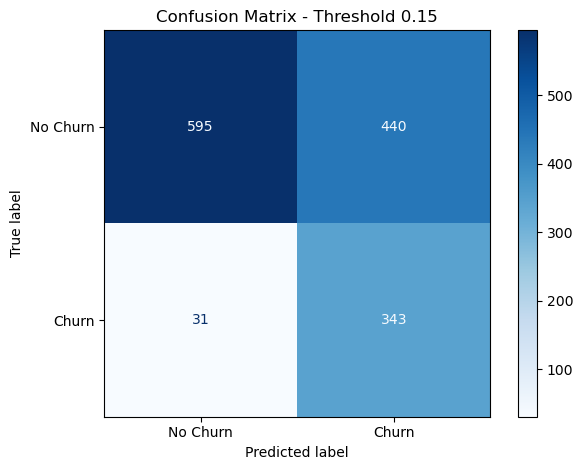

In [45]:
# Deploy decision rule
# 1) Validated actual state: Use fixed threshold of 0.15
# 2) If campaign cost changes: adjust cost_fp in the previous cell and rerun to recalculate best_threshold

best_threshold = 0.15  # currently recommended value
# best_threshold = float(best_row["threshold"])  # automatic alternative after re-optimization

final_pred = (prob_cal >= best_threshold).astype(int)

final_metrics = {
    "threshold": best_threshold,
    "accuracy": accuracy_score(y_test, final_pred),
    "precision": precision_score(y_test, final_pred, zero_division=0),
    "recall": recall_score(y_test, final_pred, zero_division=0),
    "f1": f1_score(y_test, final_pred, zero_division=0),
}

print("Usage rules:")
print("- To use fixed 0.15: keep the current line of best_threshold.")
print("- For automatic update: change to best_threshold = float(best_row['threshold']) after changing cost_fp.")
print("\nFinal metrics with active threshold:")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, display_labels=["No Churn", "Churn"], cmap="Blues")
plt.title(f"Confusion Matrix - Threshold {best_threshold:.2f}")
plt.tight_layout()
plt.show()

# Summary

- Data load and data wrangling  
- Exploratory data analysis (EDA)  
- Data preprocessing  
- One-hot enconding for categoricals  
- Standard Scaler for numericals  
- Split, training and test data  
- Models used: Logistic Regression, KNN (with best K), Gradient Boosting and Random Forest  
- Models evaluation  
- Check for overfitting and underfitting of best model: Logistic Regression 
- Feature importance  
- Pre-deploy with crossvalidation, probability calibration and threshold
- Deploy with Streamlit

# Conclusion

After all steps, we can conclude that:

- **Best base model:** Logistic Regression showed the best overall balance for this dataset.
- **Pre-deploy validation:** We ran **Stratified 5-fold cross-validation** with a leakage-safe pipeline (preprocessing inside CV), and the model remained stable across folds.
- **Probability quality:** We applied **probability calibration** (Platt scaling / sigmoid). Calibration improved probability reliability (small gain in Brier score and LogLoss), while ROC-AUC stayed practically unchanged.
- **Business-driven threshold:** Instead of using default 0.50, we optimized threshold using business costs (`cost_fn > cost_fp`) and a recall target for churn.
- **Chosen threshold:** `best_threshold = 0.15`, prioritizing churn capture (high recall) and minimizing business loss under the defined cost ratio.
- **Final decision step (deploy):** predictions are generated with calibrated probabilities using:
  
  `pred = (prob_cal >= best_threshold).astype(int)`

### Operational note

If campaign cost increases, update `cost_fp` in the threshold-tuning cell and run it again. The notebook will automatically recalculate the optimal threshold (via `best_row["threshold"]`).